Petran van Rens

BERN02 - Assignment 1


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("pollution_cleaneddata.csv")
poor = df['POOR']
mort = df['MORT']

In [2]:
def weighted_regression(x, y, k, x_0, plotting=True):

    '''
    This function performs weighted regression on the given x and y values, using the k closest points to x_0.
    x = the independent variable (POOR)
    y = the dependent variable (MORT)
    k = the number of closest points to consider
    x_0 = a vector of points at which to evaluate the regression
    plotting = whether to draw the scatter + local regression lines
    '''
    pred = np.zeros(len(x_0))
    beta_0 = np.zeros(len(x_0))
    beta_1 = np.zeros(len(x_0))
    se = np.zeros(len(x_0))

    if plotting:
        plt.scatter(poor, mort)

    for i in range(len(x_0)):
        # create table with x and y values
        matrix = [x, y]

        # Calculate the closest k values to x_0, and add to the matrix
        closest_k = np.abs(matrix[0] - x_0[i])
        matrix = np.column_stack((matrix[0], matrix[1], closest_k))
        matrix = matrix[np.argsort(matrix[:, 2])]

        # Select the first k rows of the matrix
        matrix = matrix[:k, :]

        # Calculate the weights
        weights = 1 / (matrix[:, 2] + 0.00001)
        matrix = np.column_stack((matrix, weights))

        # Extract x, y and weights
        x_local = matrix[:, 0]
        y_local = matrix[:, 1]
        w = matrix[:, 3]

        # Weighted means
        x_bar = np.sum(w * x_local) / np.sum(w)
        y_bar = np.sum(w * y_local) / np.sum(w)

        # Regression coefficients
        beta_1[i] = (
            np.sum(w * (x_local - x_bar) * (y_local - y_bar))
            / np.sum(w * (x_local - x_bar) ** 2)
        )
        beta_0[i] = y_bar - beta_1[i] * x_bar

        # Prediction at x_0
        pred[i] = beta_0[i] + beta_1[i] * x_0[i]

        # Fitted values and residuals for the local neighbourhood
        y_hat = beta_0[i] + beta_1[i] * x_local
        residuals = y_local - y_hat

        # Standard error (unweighted RMSE, matching Clara's approach)
        se[i] = np.sqrt(np.mean(residuals ** 2))

        if plotting:
            plt.scatter(x_0[i], pred[i], color='red')
            x_range = np.linspace(x_0[i] - 1, x_0[i] + 1, 5)
            y_range = beta_0[i] + beta_1[i] * x_range
            plt.plot(x_range, y_range, color='green')

    if plotting:
        plt.title('Figure 1: Scatter plot of POOR vs MORT')
        plt.xlabel("% Of families with income <$3000")
        plt.ylabel('Total age-adjusted mortality rate per 100,000')
        plt.errorbar(x_0, pred, yerr=se, fmt='o', color='black', label='Standard Error')
        plt.legend()
        plt.show()

    return pred, se

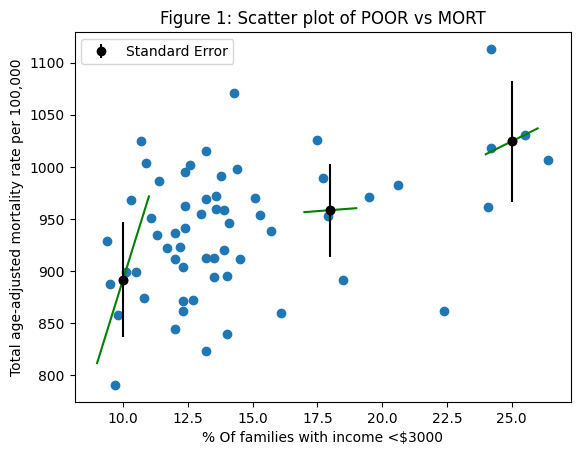

In [3]:
# Run model
pred, se = weighted_regression(poor, mort, k=11, x_0=[10, 18, 25])

This figure shows the predictions at the percentages 10%, 18% and 25%, with their standard errors

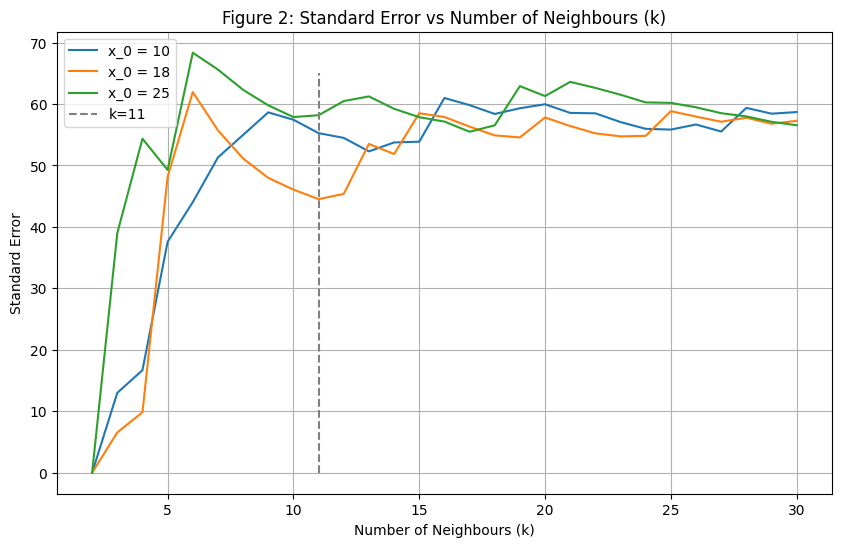

In [4]:
# Choosing k 
x_0 = [10, 18, 25]
se_10, se_18, se_25 = [], [], []
for k in range(2, 31):
    pred, se = weighted_regression(poor, mort, k, x_0, plotting=False)
    se_10.append(se[0]); se_18.append(se[1]); se_25.append(se[2])

plt.figure(figsize=(10, 6))
plt.plot(range(2, 31), se_10, label='x_0 = 10')
plt.plot(range(2, 31), se_18, label='x_0 = 18')
plt.plot(range(2, 31), se_25, label='x_0 = 25')
plt.vlines(x=11, ymin=0, ymax=65, color='grey', linestyle='--', label='k=11')
plt.title('Figure 2: Standard Error vs Number of Neighbours (k)')
plt.xlabel('Number of Neighbours (k)')
plt.ylabel('Standard Error')
plt.grid(True)
plt.legend()
plt.show()

Choice for k:

The choice for an appropriate k-value was found using the graph above. 
Using a low value for k, gives a low standard error, since the error is determined with fewest points, and the weighted average will therefore lie close to all of them and not be a good indicator. This can be seen for values before k=6.
If the value of k is too high, the prediction is not really local anymore. 
Therefore k=11 was chosen. At this value, the standard error was also relatively low.